# <center>**GALAXY CLASSIFICATION WITH MACHINE LEARNING**
    
<center><img src=https://upload.wikimedia.org/wikipedia/commons/thumb/c/c3/NGC_4414_%28NASA-med%29.jpg/310px-NGC_4414_%28NASA-med%29.jpg><center>
    
    
-<center> **Luigi Giaquinto** - N85001934<center>
-<center> **Tullio Formisano** - N85001913<center>
-<center> **Roberto di Lauro** - N85001916<center>

    
    
-<center> **CDS Fisica, a.a 2023/2024** <center>

## <center> **Obiettivi** <center>

Il progetto consiste nel **classificare morfologicamente** un dataset di galassie (la descrizione del dataset verrà data più avanti), mediante l'uso di una CNN 2D (_convolutional neural network_). La CNN in questione si propone di:

- [x] trattare dei dati in un formato facilmente gestibile
- [x] estrapolare delle features geometriche/cromatiche dai dati processati
- [x] assegnare il corrispettivo label all'immagine di partenza
    

## <center> **Morfologia delle galassie** <center>

La classificazione morfologica delle galassie è una questione astronomica di grande interesse. Riuscire a classificare correttamente le galassie è utile per aiutare a comprenderne i meccanismi evolutivi.

Introduciamo quindi la classificazione di Hubble (1936) per le galassie.

<div>
<center><img src = https://upload.wikimedia.org/wikipedia/commons/8/8a/Hubble_sequence.svg , width = 800><center>
<div/>

Le tipologie più riconoscibili sono quelle di galassia ellittica (con vari livelli di ellitticità), galassia a spirale (barrata e non) e infine galassie di forma irregolare, risultanti dalle complesse interazioni intergalattiche.
    
Tale classificazione si fondava in origine su un'evoluzione temporale da sinistra verso destra delle galassie, ma tale supposizione si è successivamente rivelata errata. Esistono classificazioni più raffinate e che tengono conto di altre _features_, ma esulano dalla nostra trattazione.



## <center> **Perché è indispensabile il Machine Learning?** <center>
    
Il Machine Learning diventa indispensabile nella catalogazione delle galassie dal momento che le survey dello spazio profondo producono grandissime quantità di dati, da analizzare spesso tramite complicati criteri. Automatizzare il processo per mezzo del Machine Learning, ed in particolare l'**apprendimento supervisionato** è quindi la soluzione che fa al caso nostro.

Il Machine Learning è una branca dell'IA che si occupa di algoritmi di autoapprendimento, capaci di sfruttare grandi quantità di dati per creare dei modelli più o meno complessi in grado di simulare il parere dell'esperto, senza essere esplicitamente programmato per fare ciò.
    
<div>
<center><img src = https://miro.medium.com/v2/resize:fit:720/format:webp/0*QYxNNYh6W9jO1b_-.png , width = 650><center>
<div/>

    
In particolare l'__apprendimento supervisionato__ consiste nella creazione di un modello che viene allenato tramite un dataset già "labellato". Tale modello dunque produce un output (quindi un label) che viene poi confrontato con quello effettivo. I "pesi" che manipolano i dati in input vengono corretti sulla base di quanto il label proposto si discosta da quello atteso.

    
<div>
<center><img src = https://blogs.nvidia.com/wp-content/uploads/2018/07/Supervised_machine_learning_in_a_nutshell.svg_-842x263.png , width = 800><center>
<div/>
    
In generale lo sviluppo del modello consiste di 3 step + 1 di test:
    
1. Preprocessing dei dati
    
2. Creazione del modello
    
3. Training
    
4. Test del modello su immagini mai viste

In [ ]:
#importiamo le librerie necessarie
import numpy as np
import matplotlib.pyplot as plt
import tables as tb
from sklearn.model_selection import train_test_split

## **Introduzione al dataset e preprocessing**

Prima ancora di approcciarci all'algoritmo di Machine Learning vero e proprio, è necessario trattare i dati, in una procedura detta **data preprocessing**. Ciò viene fatto in modo tale da avere un buon comportamento statistico tra dataset di train e dataset di test (vogliamo che il dataset sia **bilanciato**), da evitare overfitting (**augmentation**), da avere un dataset regolarizzato (evitando di dare troppo peso a valori che sono numericamente grandi).

I dati a disposizione sono un set di 10000 immagini di risoluzione 224x224 **già filtrate** (buon contrasto, abbastanza centrate e distinguibili... circa), che si presentassero ML friendly. In una situazione di analisi delle galassie reale, infatti, si incontrano una serie di problemi legati alla disposizione fisica delle galassie, il che rende il problema **nettamente** più difficile.\
Il preprocessing è così suddiviso:

1. Suddivisione del dataset in 80% (8000) train / 20% (2000) test, preservando la distribuzione dei label e dunque il bilanciamento del dataset.
    
2. Suddivisione del dataset test in 75% (1500) validation / 25% (500) test, preservando la distribuzione dei label. In tal modo abbiamo una distribuzione del dataset in 80% train / 15% validation / 5% test. Il dataset di validation è utilizzato in fase di training per avere un'informazione in real time sull'apprendimento del modello.
    
3. Acquisizione labels, rispettivamente:
    
    >0: Smooth and round\
    >1: Smooth cigar\
    >2: Edge on disk\
    >3: Unbarred spiral

4. Verifica che la distribuzione dei 4 label sia circa uniforme nei 3 gruppi di dati (verifichiamo allora il bilanciamento).

5. Normalizzazione delle immagini da int[0, 255] a float64[0., 1.]

6. *Data augmentation*


In [ ]:
#apriamo i file con PyTables (in alternativa è possibile usare h5py)
#fare attenzione a inserire il path corretto dei file hdf5
train_data = tb.open_file(r'path\to\train_dataset.hdf5')
test_data = tb.open_file(r'path\to\test_dataset.hdf5')

In [3]:
#creiamo un dizionario che associa al label "numerico" la tipologia di galassia
labels = { 0 : 'Smooth and round', 1 : 'Smooth cigar', 2 : 'Edge-on disk', 3 : 'Unbarred spiral'}

In [ ]:
#estraiamo le immagini e le label dai file hdf5, facendo attenziona alla loro struttura "ad albero")
train_images = train_data.root.images[:]
train_labels = train_data.root.labels[:]

to_split_images = test_data.root.images[:]
to_split_labels = test_data.root.labels[:]

del train_data, test_data

In [ ]:
#splittiamo il dataset in validation e test set, in modo da avere un 25% di immagini per il test e il restante 75% per la validazione
val_images, test_images, val_labels, test_labels = train_test_split(to_split_images, to_split_labels,
                                                                    test_size = 0.25, stratify = to_split_labels)

## **Visualizziamo la distribuzione di immagini**

Verifichiamo il bilanciamento del dataset:

In [ ]:
#testiamo che il dataset sia bilanciato, ovvero che ci siano lo stesso numero di immagini per ogni label, evitando bias
for i in [0, 1, 2, 3]:
    print( labels[i], ' = ', len(np.where(train_labels[:] == i)[0]))
print('Total training galaxies = ', len(train_labels[:]), '\n')

for i in [0, 1, 2, 3]:
    print( labels[i], ' = ', len(np.where(val_labels == i)[0]))
print('Total validation galaxies = ', len(val_labels[:]), '\n')

for i in [0, 1, 2, 3]:
    print( labels[i], ' = ', len(np.where(test_labels == i)[0]))
print('Total test galaxies = ', len(test_labels[:]))

Smooth and round  =  1993
Smooth cigar  =  1994
Edge-on disk  =  1993
Unbarred spiral  =  2020
Total training galaxies =  8000 

Smooth and round  =  380
Smooth cigar  =  380
Edge-on disk  =  380
Unbarred spiral  =  360
Total validation galaxies =  1500 

Smooth and round  =  127
Smooth cigar  =  126
Edge-on disk  =  127
Unbarred spiral  =  120
Total test galaxies =  500


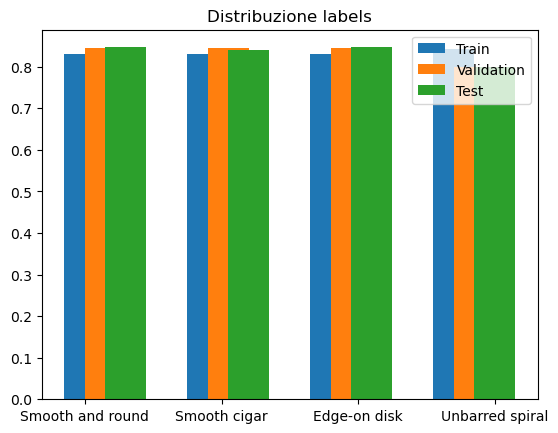

In [ ]:
#plottiamo sotto forma di istogramma la distribuzioni dei label per training, validation e test set
plt.hist(train_labels[:], align = 'left', density = True)
plt.hist(val_labels[:], align = 'mid', density = True)
plt.hist(test_labels[:], align = 'right', density = True)

plt.legend(['Train','Validation', 'Test'])
plt.xticks(range(4), [labels[i] for i in range(4)], minor = False)
plt.title("Distribuzione labels")

plt.show()

## **Visualizzazione dati**

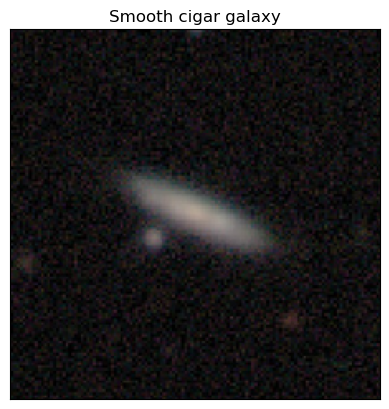

In [ ]:
index = 1 #inserire un numero qui. Per esempio, le seguenti coppie index-label sono state trovate da noi: 7 Smooth and Round, 93 Edge-on disk, 1 Smooth cigar, 2 Unbarred Spiral

plt.imshow(train_images[index])
plt.title(labels[train_labels[index]] + ' galaxy')
plt.xticks([])
plt.yticks([])

plt.show()

## **Implementazione del ML**
Arriviamo dunque al cuore del progetto, ovvero l'applicazione del **Machine Learning**.

Abbiamo utilizzato la libreria Tensorflow per la creazione della nostra rete neurale. Tale libreria è già equipaggiata con tutti gli strumenti necessari per la creazione, il training e l'analisi dei risultati dell'algoritmo di machine learning.

Per comprendere però nel dettaglio ciò che sta accadendo, è necessario avere una nozione di **rete neurale (densa)**, e della sua specializzazione alle **reti neurali convoluzionali**.

## **Cosa è una rete neurale?**

Una rete neurale è un modello di intelligenza artificiale che "insegna" al computer a elaborare i dati utilizzando processi che imitano il modo in cui i neuroni biologici lavorano insieme per identificare fenomeni, pesare le opzioni e arrivare alle conclusioni, raggiungendo grandi livelli di complessità. Tale modello crea un sistema adattivo che la macchina utilizza per imparare dai propri errori e migliorare continuamente.
___

L'architettura sulla quale si basa una DNN (_dense neural network_) sono dei layers composti da neuroni artificiali . Tali layers sono densamente connessi tra loro, con opportuni pesi e bias (valori di soglia).
E' presente un input layer che riceve i dati di training dall'ambiente, seguono poi uno o più hidden layers che analizzano l'output del livello precedente, lo elaborano uleriormente e lo trasferiscono al livello successivo; vi è poi un layer di output che restituisce il risultato dell'elaborazione dei dati attraverso la rete e il cui numero di neuroni generalmente corrisponde al numero di classi sulle quali si sta facendo l'addestramento (classificazione multi-classe come nel nostro caso).
___

All'uscita di ogni neurone abbiamo una **funzione di attivazione**, che ha il compito di introdurre non linearità negli output dei neuroni in modo tale da aumentare la complessità del modello.
___
E' possibile pensare ai dati che fluiscono dall'input all'output (_forward propagation_).
La rete artificiale impara continuamente utilizzando feedback correttivi, migliorando le proprie analisi predittive: realizza ciò tramite la backpropagation, la quale fa si che ogni neurone assegni un peso maggiore al "percorso" che conduce ad una predizione più vicina a quella reale, viceversa per una sbagliata.

<center> <img src= https://miro.medium.com/v2/resize:fit:1400/1*SCz0aTETjTYC864Bqjt6Og.png , width=700> <center>

##  **Perchè è necessaria una CNN?**
    
Un classico Feedforward Neural Network, FNN, ha 2 grosse limitazioni riguardo la classificazione di immagini:

- Non gestisce bene input di grosse dimensioni, ricordiamo che un'immagine RGB è un file di tipo (width, height, 3)
- Rischia l'overfitting, in quanto non estrapola le features (morfologiche nel nostro caso). Ovvero: non è capace di separare la feature dalla sua posizione nell'immagine, incorrendo in alcuni errori (ad esempio, se il training è fatto su immagini asimmetriche, "mostrando" una delle immagini flippate, ho dei problemi)

<center><img src= https://miro.medium.com/v2/1*Ne7jPeR6Vrl1f9d7pLLG8Q.jpeg> <center>

   
<p>Una CNN presenta alcuni vantaggi: é in grado di estrapolare le features dell'immagine risolvendo:
    
> Il problema della dimensionalità
>
> Il problema della dipendenza spaziale di una FNN
</p>

<center><img src= https://training.galaxyproject.org/training-material/topics/statistics/images/Conv_multiple_channel_3d.gif><center>
    

In [ ]:
#importiamo le librerie necessarie per la costruzione della CNN
import tensorflow as tf
from tensorflow import keras
from keras import Sequential, layers, models

In [ ]:
#creiamo un rescaler per normalizzare le immagini, in modo che i valori dei pixel siano compresi tra 0 e 1
rescale = tf.keras.Sequential([layers.Rescaling(scale = 1./255)])

In [ ]:
#riscaliamo le immagini di training, validation e test set
train_images = rescale(train_images)
val_images = rescale(val_images)
test_images = rescale(test_images)

In [ ]:
#definiamo il layer di augmentation (la scelta di creare un layer, piuttosto che applicare l'augmentation prima della compilazione del modello è dettata da problematiche di memoria)
augment = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"), #comprendiamo riflessioni orizzontali e verticali, in quanto le galassie non hanno un orientamento preferenziale (flip)
    layers.RandomRotation(factor = 0.5)])  #comprendiamo anche rotazioni casuali, in quanto le galassie non hanno un orientamento preferenziale (rotation)

## **Creazione della Rete Neurale**

<center> <img src=https://training.galaxyproject.org/training-material/topics/statistics/images/Conv_CNN.png alt= "Fully Connected Layer"> <figcaption> <font> CNN con 3 layer convoluzionali, seguiti dal pooling layer, e un fully connected layer finale <center>

<p>
<font>
La nostra rete neurale è così strutturata:
<p>
    
1.Il primo layer è di augmentation; abbiamo deciso di inserirla in un layer per risparmiare memoria\
2.Seguono due layer convoluzionali con 32 filtri, rispettivamente (8,8) e (4,4). La scelta dei filtri è stata fatta considerando le dimensioni dell'immagine, cercando di minimizzare il numero di pesi.\
3.Segue il primo layer di maxPooling\
4.Abbiamo altri due layer di convoluzionale + maxPooling\
5.Infine, il fully connected (che si occupa del labeling)
<p>
Abbiamo usato come activation ReLu per i layer convoluzionali, SoftMax per l'output layer.
L'optimizer è Adam, non abbiamo notato miglioramenti con gli altri optimizer. gas


In [ ]:
model = models.Sequential()

model.add(augment) #layer di augmentation: rotazione e flip casuali per evitare overfitting ed 'aumentare' il dataset

#primo layer convoluzionale
model.add(layers.Conv2D(32, (8, 8), input_shape = (224, 224, 3), strides = (1, 1), activation = 'relu'))
model.add(layers.Conv2D(32, (4, 4), strides = (1, 1), activation = 'relu'))
model.add(layers.MaxPooling2D((4, 4)))

#secondo layer convoluzionale
model.add(layers.Conv2D(32, (4, 4), strides = (1, 1), activation = 'relu'))
model.add(layers.MaxPooling2D((2, 2)))

#terzo layer convoluzionale
model.add(layers.Conv2D(32, (2, 2), strides = (1, 1), activation = 'relu'))

#layer 'fully connected'
model.add(layers.Flatten())
model.add(layers.Dense(32, activation = 'relu'))
model.add(layers.Dense(4, activation = 'softmax')) #labeling avviene in quest'ultimo layer, si noti infatti la funzione di attivazione softmax, che restituisce un array di probabilità per ogni label

In [ ]:
#possiamo testare se il mio modello sta "indovinando", ovvero: ogni label ha la stessa probabilità di essere predetta, quindi dovremmo avere 1/4 = 0.25 come appartenenza per ogni label
guess = model(test_images[:10])
print('\n \n', guess[1])


 
 tf.Tensor([0.24932985 0.25335273 0.24757631 0.24974096], shape=(4,), dtype=float32)


In [ ]:
model.summary() #visualizziamo i layer e il numero di parametri su cui andiamo ad ottimizzare, ci facciamo un'idea della complessità del modello e di quanto tempo ci vorrà per addestrarlo

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 217, 217, 32)      6176      
                                                                 
 conv2d_1 (Conv2D)           (None, 214, 214, 32)      16416     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 53, 53, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 50, 50, 32)        16416     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 25, 25, 32)       0         
 2D)                                                  

In [ ]:
#compiliamo il modello una volta definita la sua architettura, l'ottimizzatore scelto è Adam, la loss function è la SparseCategoricalCrossentropy (perchè abbiamo 4 label) e come metrica di valutazione scegliamo l'accuracy
model.compile(optimizer = 'adam',
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = ['accuracy'])

In [ ]:
#training del modello
history = model.fit(train_images, train_labels, epochs = 128,
                    validation_data = (val_images, val_labels),
                    callbacks = keras.callbacks.EarlyStopping(monitor = 'val_accuracy', mode='max', patience = 8, min_delta = 0))

Epoch 1/128
250/250 [==============================] - 341s 1s/step - loss: 1.2613 - accuracy: 0.3811 - val_loss: 0.9517 - val_accuracy: 0.5860
Epoch 2/128
250/250 [==============================] - 327s 1s/step - loss: 0.8210 - accuracy: 0.6341 - val_loss: 0.6836 - val_accuracy: 0.7013
Epoch 3/128
250/250 [==============================] - 326s 1s/step - loss: 0.6700 - accuracy: 0.7138 - val_loss: 0.6104 - val_accuracy: 0.7107
Epoch 4/128
250/250 [==============================] - 327s 1s/step - loss: 0.6145 - accuracy: 0.7375 - val_loss: 0.5885 - val_accuracy: 0.7373
Epoch 5/128
250/250 [==============================] - 326s 1s/step - loss: 0.5676 - accuracy: 0.7606 - val_loss: 0.5512 - val_accuracy: 0.7653
Epoch 6/128
250/250 [==============================] - 327s 1s/step - loss: 0.5399 - accuracy: 0.7709 - val_loss: 0.5082 - val_accuracy: 0.7840
Epoch 7/128
250/250 [==============================] - 330s 1s/step - loss: 0.5191 - accuracy: 0.7809 - val_loss: 0.4714 - val_accuracy:

## <center>**Analisi dei risultati del modello predittivo**<center>
    
Visualizziamo di seguito i risultati del nostro semplice modello,
ponendo l'attenzione sulle criticità e su ciò che il modello è capace di fare.

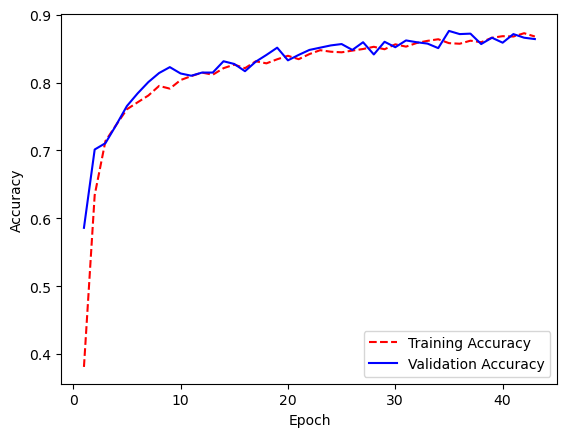

In [ ]:
#mostriamo la storia del training e della validazione
training_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs = range(1, len(training_accuracy) + 1)

plt.plot(epochs, training_accuracy, 'r--')
plt.plot(epochs, val_accuracy, 'b-')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.show()

In [ ]:
#prediction del modello sul database test: questa restituisce i "gradi di appartenenza" ad ogni tipo di galassia
pred_on_test = model.predict(test_images)

16/16 [==============================] - 4s 250ms/step


In [ ]:
#estraiamo i risultati della prediction
predicted_labels = [ np.where(pred_on_test[i] == np.max(pred_on_test[i])) for i in range(len(pred_on_test))]
predicted_labels = [predicted_labels[i][0][0] for i in range(len(predicted_labels))]

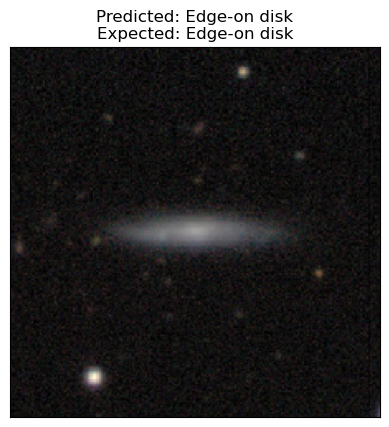

In [ ]:
index = 155
plt.imshow(test_images[index])
plt.title('Predicted: ' +  str(labels[predicted_labels[index]]) + '\n' + 'Expected: ' + str(labels[test_labels[index]]))
plt.xticks([])
plt.yticks([])
plt.show()

## <center> <font> **Matrice di confusione** <center>

La matrice di confusione è uno degli strumenti che permettono di dare un'indicazione sulla bontà del modello. Tramite questa matrice possiamo vedere anche eventuali criticità del modello. Riportiamo anche le seguenti metriche: _recall_ (predizioni corrette / tutte le predizioni), _precision_ (predizioni corrette / tutte le galassie attese)

In [ ]:
from tensorflow import math
from matplotlib import colormaps

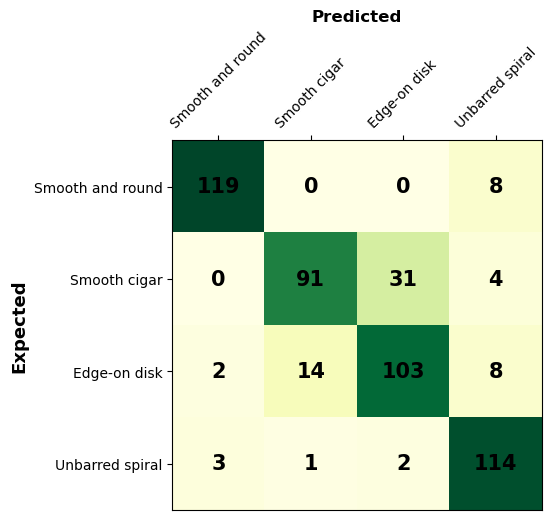

In [ ]:
#creiamo la matrice di confusione, con una semplice funzione di tensorflow, che ci permette di capire quanto il nostro modello sia accurato
ConfusionMatrix = tf.math.confusion_matrix(
    test_labels,
    predicted_labels,
    num_classes = 4)

fig, ax = plt.subplots()

ax.imshow(ConfusionMatrix, cmap = 'YlGn')
ax.grid(False)
ax.tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
plt.xticks(range(4), [labels[i] for i in range(4)], minor = False, rotation = 45)
plt.yticks(range(4), [labels[i] for i in range(4)], minor = False)

x_start = -1
x_end = 2
y_start = -1
y_end = 2
jump_x = 1
jump_y = 1
x_positions = np.linspace(start = x_start, stop = x_end, num = 4, endpoint = True)
y_positions = np.linspace(start = y_start, stop = y_end, num = 4, endpoint = True)
for y_index, y in enumerate(y_positions):
    for x_index, x in enumerate(x_positions):
        #print(int(ConfusionMatrix[y_index, x_index]))
        label = int(ConfusionMatrix[y_index, x_index])
        text_x = x + jump_x
        text_y = y + jump_y
        ax.text(text_x, text_y, label, color='black', ha='center', va='center',
                fontweight = 700, fontsize = 15)

ax.set_title('Predicted', fontweight = 1000)
plt.ylabel('Expected', fontsize = 13, fontweight = 1000)

plt.show()

In [ ]:
#calcoliamo la traccia della matrice di confusione, che ci permette di capire quante immagini sono state classificate correttamente, e quindi l'accuracy del modello
print("Traccia = ", np.trace(ConfusionMatrix), "\nAccuracy = ", np.trace(ConfusionMatrix)/5, "% \n")

#calcoliamo e stampiamo precision e recall per ogni label, in modo da capire quanto il nostro modello sia accurato nel predire ogni tipo di galassia
for i in range(4):
    print("La somma sulla riga", labels[i], "è ", np.sum(ConfusionMatrix[i, :])) #Questo è il numero totale di galassie dell'i-esimo tipo nel dataset
    print("La somma sulla colonna", labels[i] , "è ", np.sum(ConfusionMatrix[:, i])) #Questo è il numero totale di galassie dell'i-esimo tipo predette dalla rete neurale
    print("   Recall(", str(labels[i]), ") = ", np.sum(ConfusionMatrix[i, i]) / np.sum(ConfusionMatrix[i, :]), )
    print("   Precision(", str(labels[i]), ") = ", np.sum(ConfusionMatrix[i, i]) / np.sum(ConfusionMatrix[:, i]), "\n")

Traccia =  427 
Accuracy =  85.4 % 

La somma sulla riga Smooth and round è  127
La somma sulla colonna Smooth and round è  124
   Recall( Smooth and round ) =  0.937007874015748
   Precision( Smooth and round ) =  0.9596774193548387 

La somma sulla riga Smooth cigar è  126
La somma sulla colonna Smooth cigar è  106
   Recall( Smooth cigar ) =  0.7222222222222222
   Precision( Smooth cigar ) =  0.8584905660377359 

La somma sulla riga Edge-on disk è  127
La somma sulla colonna Edge-on disk è  136
   Recall( Edge-on disk ) =  0.8110236220472441
   Precision( Edge-on disk ) =  0.7573529411764706 

La somma sulla riga Unbarred spiral è  120
La somma sulla colonna Unbarred spiral è  134
   Recall( Unbarred spiral ) =  0.95
   Precision( Unbarred spiral ) =  0.8507462686567164 



## **Problema Smooth Cigar - Edge On**

Si osserva dalla matrice di confusione che vi è una criticità nella predizione dei label "smooth cigar" ed "edge on". Tale problema è comprensibile se si guarda ad alcune delle galassie appartenenti a queste due categorie. Ci sono un buon numero di features che le accomunano, e delle sottigliezze che le distinguono (galactic bulge più pronunciata, presenza di gas e polveri IN PIANO, colori diversi).

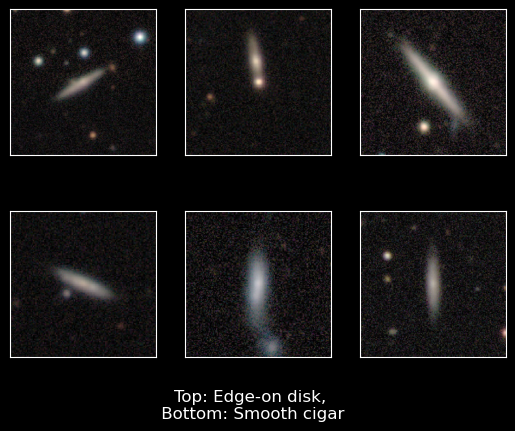

In [ ]:
fig, axis = plt.subplots(2, 3)

plt.style.use('dark_background')

axis[0, 0].imshow(train_images[78])
axis[0, 1].imshow(train_images[11])
axis[0, 2].imshow(train_images[12])
axis[1, 0].imshow(train_images[1])
axis[1, 1].imshow(train_images[0])
axis[1, 2].imshow(train_images[3])

for i in range(2):
    for j in range(3):
        axis[i, j].set_xticks([])
        axis[i, j].set_yticks([])

txt = "Top: Edge-on disk,\n Bottom: Smooth cigar" #La differenza sta nella presenza di una galactic bulge pronunciata (edge on disk)
plt.figtext(0.5, 0.01, txt, wrap=True, horizontalalignment='center', fontsize=12)
plt.show()

Nelle immagini ad altissima definizione disponibili, le differenze citate sopra sono notevolmente accentuate.
<table><tr>
<td> <img src="https://www.universetoday.com/wp-content/uploads/2009/02/ngc4565.jpg" alt="Drawing" style="width: 350px;"/> </td>
<td> <img src="https://www.people.vcu.edu/~rgowdy/astro/image/galaxies/m82a.jpg" alt="Drawing" style="width: 350px;"/> </td>
</tr></table>

## Possibili migliorie

Si potrebbe pensare di mitigare il problema con la creazione di una seconda rete neurale specializzata solo sulla classificazione tra smooth cigar ed edge on, o alternativamente scegliere un dataset con immagini a risoluzione più alta.